<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/Nesterov_Accelerated__Gradient(NAG).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

When training deep learning models, optimization algorithms help us find the best weights.

But simple Gradient Descent is slow and can get stuck.

-> Momentum improves speed

-> Nesterov Momentum improves accuracy + stability

**Problem with Momentum**

Momentum helps accelerate learning:

v = βv + learning_rate * gradient
w = w - v

=> Problem:
* It can overshoot the minimum
* Especially in valleys (zig-zag path)

**What is Nesterov Momentum (NAG)?**

Instead of calculating gradient at current position:


=> NAG calculates gradient at future (look-ahead) position

lookahead = w - βv

gradient = grad(lookahead)

v = βv + learning_rate * gradient

w = w - v

**Why NAG is Better?**

-> Reduces overshooting

-> Slows down near minima

-> Faster convergence

-> More stable training

**Classification using TensorFlow**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize

x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def create_model():
  model = keras.Sequential([
      layers.Flatten(input_shape=(28,28)),
      layers.Dense(128, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model


In [5]:
model_sgd = create_model()

model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8185 - loss: 0.6714 - val_accuracy: 0.9087 - val_loss: 0.3179
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9165 - loss: 0.2932 - val_accuracy: 0.9272 - val_loss: 0.2495
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9320 - loss: 0.2399 - val_accuracy: 0.9385 - val_loss: 0.2129
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9415 - loss: 0.2050 - val_accuracy: 0.9440 - val_loss: 0.1854
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9488 - loss: 0.1798 - val_accuracy: 0.9492 - val_loss: 0.1669


In [6]:
model_momentum = create_model()

model_momentum.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_momentum = model_momentum.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9122 - loss: 0.2929 - val_accuracy: 0.9563 - val_loss: 0.1382
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9632 - loss: 0.1193 - val_accuracy: 0.9679 - val_loss: 0.1033
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9752 - loss: 0.0816 - val_accuracy: 0.9725 - val_loss: 0.0898
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9808 - loss: 0.0628 - val_accuracy: 0.9755 - val_loss: 0.0755
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9842 - loss: 0.0503 - val_accuracy: 0.9747 - val_loss: 0.0791


In [7]:
model_nag = create_model()

model_nag.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_nag = model_nag.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9159 - loss: 0.2838 - val_accuracy: 0.9510 - val_loss: 0.1628
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9641 - loss: 0.1208 - val_accuracy: 0.9682 - val_loss: 0.0997
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9744 - loss: 0.0843 - val_accuracy: 0.9707 - val_loss: 0.0974
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9806 - loss: 0.0636 - val_accuracy: 0.9738 - val_loss: 0.0809
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9842 - loss: 0.0498 - val_accuracy: 0.9742 - val_loss: 0.0768


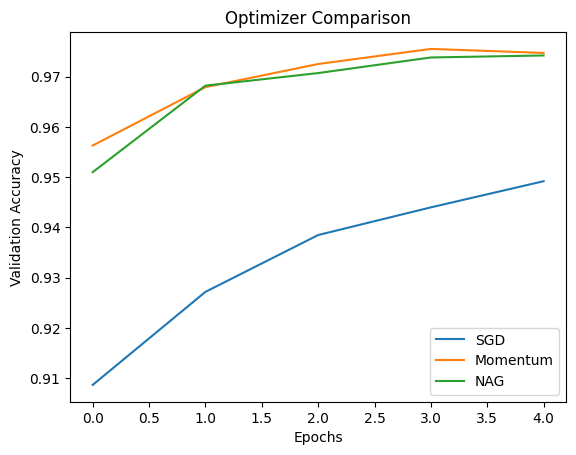

In [8]:
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_momentum.history['val_accuracy'], label='Momentum')
plt.plot(history_nag.history['val_accuracy'], label='NAG')

plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()